# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Clase 3 — Ingeniería de atributos

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

Este notebook parte de la **base mínima heredada** de las Clases 1 y 2 (carga, target, features y decisiones ya cerradas — sin repetir el EDA ni las comparaciones intermedias, que quedan documentadas en esos notebooks) y dedica el cuerpo principal a la Clase 3: ingeniería de atributos. La idea de la clase es simple pero central — *el modelo no es solo el algoritmo, es datos + features + preprocesamiento + algoritmo + hiperparámetros + validación* — así que todo lo que sigue son intentos de mejorar esa ecuación completa, cada uno medido contra la misma vara: la CV temporal de ventana expansiva que ya validamos en la Clase 2.

## Base heredada de las Clases 1–2 (mínima)

Carga, target, las tres features derivadas de la Clase 1 (`content_type`, `hora`, `dia_semana`, `artista_top`), el esquema de validación temporal de la Clase 2 (test interno + CV de ventana expansiva) y la receta ganadora del árbol (hiperparámetros + ventana de datos). Justificación completa de cada decisión en `tp_spotify_clase1_knn.ipynb` y `tp_spotify_clase2_arboles_2.ipynb` — acá solo el resultado, para no repetir EDA ni comparaciones ya hechas.

**Una decisión que quedaba pendiente de la Clase 2:** si sumar `user_id` (con la CV temporal sumaba +0.0146, contradiciendo el holdout único original). La dejamos afuera de esta base y la resolvemos más abajo, dentro del cuerpo de la Clase 3, junto con las features nuevas — es un experimento más al que aplicarle el mismo protocolo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "competition_data"

# Estilo unico para todos los graficos del notebook (paleta validada para daltonismo).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_track_name", "master_metadata_album_artist_name",
    "master_metadata_album_album_name",
    "spotify_track_uri", "episode_name", "episode_show_name", "spotify_episode_uri",
    "audiobook_title", "audiobook_uri", "audiobook_chapter_uri", "audiobook_chapter_title",
    "shuffle", "offline", "offline_timestamp", "incognito_mode", "user_id",
]
DTYPES = {
    "spotify_track_uri": "string", "spotify_episode_uri": "string",
    "audiobook_uri": "string", "audiobook_chapter_uri": "string",
}
# Sumamos mas columnas que en la Clase 2 (track_name, album_name, episode_show_name,
# audiobook_*, offline_timestamp): la Clase 3 las necesita para probar is_missing flags
# y one-hot sin tope. Ninguna estaba prohibida antes, simplemente no hacian falta.

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

print("Filas:", len(train_raw))
print("Proporcion de abandono temprano (target=1):", train_raw["target"].mean().round(4))
train_raw[["obs_id", "ms_played", "target"]].head()

Filas: 911344
Proporcion de abandono temprano (target=1): 0.278


,obs_id,ms_played,target
0,1,8956,1
1,2,202024,0
2,3,269480,0
3,4,24299,1
4,5,97877,0


In [3]:
# Tres derivadas de la Clase 1 (justificacion completa en ese notebook, aca solo el resultado):
# content_type (que URI esta presente), hora/dia_semana (de ts, en UTC), artista_top (top 50
# de train, resto -> "otros"; calculado solo con train, anti-fuga).

train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)

ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# Orden cronologico + obs_id como desempate: lo vamos a necesitar mas abajo para calcular
# recencia y conteos por usuario respetando el orden real dentro de un mismo timestamp redondeado.
train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

print("Features derivadas listas. artista_top:", train_raw["artista_top"].nunique(), "categorias (incluye 'otros').")

Features derivadas listas. artista_top: 51 categorias (incluye 'otros').


### Esquema de validación y receta ganadora (Clase 2, sin repetir la búsqueda)

Mismo esquema que cerramos en la Clase 2: **`test_interno`** (15% más reciente, se toca una única vez al final) y, dentro del 85% restante, **CV temporal de ventana expansiva** (4 folds: cada uno entrena con el pasado y valida con el bloque siguiente) para tomar todas las decisiones de este notebook. Nunca K-Fold aleatorio ni mezclar épocas — el profesor fue explícito en que el TP tiene componente temporal.

La función de preprocesamiento ahora admite dos tipos de columnas por separado: **categóricas** (van por `OneHotEncoder`, igual que antes) y **numéricas** (pasan directo, sin one-hot). Hace falta porque varias ideas de la Clase 3 (recencia, conteos, tasas) son continuas — convertirlas a texto y one-hot-encodearlas les haría perder la magnitud y el orden, exactamente lo que la clase advierte que no hay que hacer.

La receta ganadora de la Clase 2 (`max_depth=14, min_samples_leaf=100, min_samples_split=50, α=1e-4`, ventana de 24 meses) queda fija como punto de partida: **la reproducimos primero para confirmar que la base heredada está bien** antes de sumar nada nuevo.

In [4]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
MEJOR_PARAMS = dict(max_depth=14, min_samples_leaf=100, min_samples_split=50, min_impurity_decrease=1e-4)
VENTANA_TRAIN_MESES = 24


def build_xy(df, cat_features, num_features=()):
    X_cat = df[list(cat_features)].fillna("missing").astype(str) if cat_features else pd.DataFrame(index=df.index)
    X_num = df[list(num_features)].astype(float).fillna(0.0) if num_features else pd.DataFrame(index=df.index)
    return pd.concat([X_cat, X_num], axis=1), df["target"]


def build_tree_pipeline(cat_features, num_features=(), **tree_kwargs):
    transformers = []
    if cat_features:
        transformers.append(("onehot", OneHotEncoder(handle_unknown="ignore"), list(cat_features)))
    if num_features:
        transformers.append(("num", "passthrough", list(num_features)))
    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return Pipeline([("preprocessor", preprocessor),
                      ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_kwargs))])


def make_expanding_folds(df, n_folds=4):
    """Folds temporales de ventana expansiva. df debe venir ordenado cronologicamente."""
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_train = np.arange(0, bordes[i])
        idx_val = np.arange(bordes[i], bordes[i + 1])
        if len(idx_val) > 0 and len(idx_train) > 0:
            folds.append((idx_train, idx_val))
    return folds


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def cv_temporal_auc(df, cat_features, num_features, pipeline_factory, n_folds=4,
                     train_filter=None, row_prep=None, random_state=RANDOM_STATE):
    """AUC promedio en validacion con ventana expansiva temporal. row_prep(df_tr, df_va) es
    opcional: para features que se calculan DENTRO de cada fold (p. ej. target encoding),
    usando solo el train de ese fold -- la forma anti-fuga que exige la Clase 3."""
    aucs = []
    for idx_tr, idx_val in make_expanding_folds(df, n_folds):
        df_tr, df_va = df.iloc[idx_tr], df.iloc[idx_val]
        if train_filter is not None:
            df_tr = train_filter(df_tr)
        if row_prep is not None:
            df_tr, df_va = row_prep(df_tr, df_va)
        X_tr, y_tr = build_xy(df_tr, cat_features, num_features)
        X_va, y_va = build_xy(df_va, cat_features, num_features)
        pipe = pipeline_factory(cat_features, num_features)
        pipe.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_va, pipe.predict_proba(X_va)[:, 1]))
    return float(np.mean(aucs)), aucs


def eval_features(df_train, cat_features, num_features=(), params=None, ventana=VENTANA_TRAIN_MESES,
                   n_folds=4, row_prep=None):
    """Atajo: CV temporal con la receta ganadora de hiperparametros, solo cambiando features."""
    params = params or MEJOR_PARAMS
    factory = lambda cf, nf: build_tree_pipeline(cf, nf, **params)
    filtro = (lambda d, m=ventana: filtrar_reciente(d, m)) if ventana is not None else None
    return cv_temporal_auc(df_train, cat_features, num_features, factory, n_folds=n_folds,
                            train_filter=filtro, row_prep=row_prep)

In [5]:
n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()

for nombre, df in [("train", df_train), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

auc_baseline, _ = eval_features(df_train, TODAS_LAS_FEATURES)
print(f"\nAUC CV temporal heredado de la Clase 2 (sin cambios todavia): {auc_baseline:.4f}")
print("Este es el numero a superar en el resto del notebook.")

train          774642 filas | 2013-10-29 -> 2023-05-26 | tasa abandono 0.2865
test interno   136702 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298

AUC CV temporal heredado de la Clase 2 (sin cambios todavia): 0.6885
Este es el numero a superar en el resto del notebook.


## Ingeniería de atributos (Clase 3)

La clase repasa un catálogo grande de técnicas (log, estandarización, discretización, one-hot, bin counting, interacciones, missing values, feature selection) y es explícita en un punto: **nada de esto se adopta por intuición — cada transformación se prueba contra la validación, y se descarta si no mejora** (el propio ejemplo de la clase: logaritmo solo mejoraba, estandarizar solo mejoraba más, pero log+estandarizar combinado empeoraba respecto de estandarizar solo). Vamos a seguir exactamente ese protocolo: una idea, un número de CV temporal, se adopta si supera al mejor número vigente.

Orden de exploración, de más simple/barato a más costoso:
1. **Calendario** — fin de semana, codificación cíclica de hora/día/año.
2. **Comportamiento de sesión** — recencia y conteos (la zona con más potencial, según el propio ejemplo del profesor sobre Spotify).
3. **Bin counting / target encoding** — y con eso, resolver el pendiente de `user_id`.
4. **One-hot sin tope** — matrices ralas para categóricas de alta cardinalidad.
5. **Missing values** — indicadores de ausencia.

### 1. Calendario: fin de semana y codificación cíclica

Hoy `hora` y `dia_semana` entran al pipeline como texto → `OneHotEncoder`, es decir, **24 categorías sin relación entre sí** para la hora (el árbol no sabe que las 23 y las 0 son casi lo mismo) y 7 para el día. Tres ideas, todas puramente por-fila (dependen solo del `ts` de esa misma fila, igual que un `log(x)` — sin riesgo de fuga):

- **`es_finde`**: flag binario fin de semana. Con `dia_semana` ya one-hot, el árbol necesita 2 splits (sábado, domingo) para aislarlo; un flag se lo da en 1 solo split.
- **Codificación cíclica seno/coseno** de `hora` y `dia_semana`: en vez de categorías sueltas, dos columnas numéricas que capturan la adyacencia circular (23h y 0h quedan cerca en el espacio seno/coseno). Es la aplicación directa del ejemplo de apertura de la clase — representar la estructura circular para que el modelo la aproveche.
- **Día del año** (cíclico): estacionalidad. Ojo con la propia advertencia que ya habíamos anotado en la Clase 2 sobre features de calendario "time-absolute" (`mes`/`año` no generalizan de train, 2013–2024, a test, solo sep–dic 2024) — día del año cae en zona de cautela parecida, así que lo probamos igual y dejamos que el número decida.

In [6]:
for df in (df_train, df_test_interno):
    df["es_finde"] = df["dia_semana"].isin(["sáb", "dom"]).astype(int)
    doy = df["ts_dt"].dt.dayofyear
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)
    dow = df["ts_dt"].dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

CAT_SIN_HORA_DIA = [f for f in TODAS_LAS_FEATURES if f not in ("hora", "dia_semana")]
resultados_calendario = {"baseline (hora + dia_semana one-hot)": auc_baseline}

auc, _ = eval_features(df_train, TODAS_LAS_FEATURES + ["es_finde"])
resultados_calendario["+ es_finde"] = auc

auc, _ = eval_features(df_train, CAT_SIN_HORA_DIA + ["dia_semana"], ["hora_sin", "hora_cos"])
resultados_calendario["hora -> seno/coseno"] = auc

auc, _ = eval_features(df_train, CAT_SIN_HORA_DIA + ["hora"], ["dow_sin", "dow_cos"])
resultados_calendario["dia_semana -> seno/coseno"] = auc

auc, _ = eval_features(df_train, CAT_SIN_HORA_DIA, ["hora_sin", "hora_cos", "dow_sin", "dow_cos"])
resultados_calendario["hora Y dia_semana -> seno/coseno"] = auc

auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["doy_sin", "doy_cos"])
resultados_calendario["+ dia_del_año (seno/coseno)"] = auc

print(f"{'Variante':45s} {'AUC CV':>8s}   {'Δ vs. baseline':>14s}")
for k, v in resultados_calendario.items():
    print(f"{k:45s} {v:8.4f}   {v - auc_baseline:+.4f}")

Variante                                        AUC CV   Δ vs. baseline
baseline (hora + dia_semana one-hot)            0.6885   +0.0000
+ es_finde                                      0.6840   -0.0045
hora -> seno/coseno                             0.6850   -0.0036
dia_semana -> seno/coseno                       0.6828   -0.0057
hora Y dia_semana -> seno/coseno                0.6851   -0.0034
+ dia_del_año (seno/coseno)                     0.6761   -0.0124


**Veredicto: ninguna se adopta.** Las cuatro variantes quedan entre -0.0034 y -0.0124 respecto del baseline — la de día del año es la única caída que se aleja del ruido de fold a fold (los folds individuales del baseline van de 0.63 a 0.74, así que diferencias de pocos milésimos entran dentro de esa variabilidad). Es exactamente lo que la clase anticipa: una transformación que suena razonable ("representar mejor lo cíclico", "aislar el fin de semana en un split") no garantiza nada — sin la validación no lo hubiéramos sabido, y acá la validación dice que no. Seguimos con `hora`/`dia_semana` one-hot tal como estaban.

### 2. Comportamiento de sesión: recencia y conteos

Acá es donde el profesor da el ejemplo casi textual para Spotify: contar cuántas reproducciones caen en la misma media hora para un mismo usuario, razonando que si aparecen 90 canciones en 30 minutos, varias necesariamente se cortaron ("un poco de trampa, pero sirve", dice él mismo). Probamos varias variantes, todas calculadas sobre el historial ordenado de cada usuario — dependen solo de `user_id` + `ts`/`obs_id` de cada fila (nunca del target), igual que `artista_top`, así que no hay riesgo de fuga por acá:

- **`gap_min`**: minutos desde la reproducción anterior del mismo usuario (recencia). Primera reproducción de cada usuario → -1 (sentinela).
- **Sesión**: definimos el corte de sesión en `gap_min > 30` (más de un bloque de 30 min vacío entre reproducciones = sesión nueva). Con eso, `pos_en_sesion` (crudo) es literalmente la idea que propusiste: cuántas canciones vinieron antes en esta sesión. También la versión bucketizada (0, 1-5, 6-10, 11-20, 21-50, 50+).
- **`bucket_count_30min`**: la versión textual del profesor — cuántas filas comparten usuario + el mismo `ts` redondeado a 30 min (incluye filas que, dentro de ese bloque, podrían ir "después" de la fila actual — ver la nota de honestidad más abajo).
- **`session_total_count`**: variante propia, a mitad de camino — total de canciones en la sesión completa (no solo las previas), pero agrupando por sesión real (gap > 30 min) en vez de por coincidencia exacta de timestamp.

In [7]:
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

gap = full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
full["gap_min"] = gap.fillna(-1)  # -1 = primera reproduccion de ese usuario en el dataset

UMBRAL_SESION_MIN = 30
nueva_sesion = (full["gap_min"] < 0) | (full["gap_min"] > UMBRAL_SESION_MIN)
full["session_id"] = nueva_sesion.groupby(full["user_id"]).cumsum()
full["pos_en_sesion"] = full.groupby(["user_id", "session_id"]).cumcount()

bins = [-1, 0, 5, 10, 20, 50, np.inf]
labels = ["0", "1-5", "6-10", "11-20", "21-50", "50+"]
full["pos_en_sesion_bucket"] = pd.cut(full["pos_en_sesion"], bins=bins, labels=labels).astype(str)

full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["session_total_count"] = full.groupby(["user_id", "session_id"])["obs_id"].transform("size")

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

print("Sesiones detectadas:", full["session_id"].nunique(), "en", full["user_id"].nunique(), "usuarios (corte:", UMBRAL_SESION_MIN, "min)")

resultados_sesion = {"baseline": auc_baseline}
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["gap_min"])
resultados_sesion["+ gap_min (recencia)"] = auc
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["pos_en_sesion"])
resultados_sesion["+ pos_en_sesion (conteo crudo, tu idea)"] = auc
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES + ["pos_en_sesion_bucket"])
resultados_sesion["+ pos_en_sesion_bucket (bucketizado)"] = auc
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["session_total_count"])
resultados_sesion["+ session_total_count (total de la sesion real)"] = auc
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["bucket_count_30min"])
resultados_sesion["+ bucket_count_30min (ejemplo del profesor)"] = auc
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, ["gap_min", "bucket_count_30min"])
resultados_sesion["+ gap_min + bucket_count_30min (los 2 mejores juntos)"] = auc

print(f"\n{'Variante':50s} {'AUC CV':>8s}   {'Δ vs. baseline':>14s}")
for k, v in resultados_sesion.items():
    print(f"{k:50s} {v:8.4f}   {v - auc_baseline:+.4f}")

Sesiones detectadas: 8338 en 10 usuarios (corte: 30 min)

Variante                                             AUC CV   Δ vs. baseline
baseline                                             0.6885   +0.0000
+ gap_min (recencia)                                 0.7145   +0.0260
+ pos_en_sesion (conteo crudo, tu idea)              0.6939   +0.0054
+ pos_en_sesion_bucket (bucketizado)                 0.6934   +0.0049
+ session_total_count (total de la sesion real)      0.6786   -0.0099
+ bucket_count_30min (ejemplo del profesor)          0.8024   +0.1139
+ gap_min + bucket_count_30min (los 2 mejores juntos)   0.8122   +0.1237


**`bucket_count_30min` sube el AUC más de 0.11 puntos — un salto enorme.** La clase es explícita: *"el mejor diagnóstico de que estás haciendo data leakage es que tu modelo anda demasiado bien"*. Antes de festejarlo, hay que desconfiar en serio. Dos chequeos:

1. **¿Es señal real o un bug?** Abajo comparamos la tasa de abandono *real* (no predicha) por decil de `bucket_count_30min`. Si el conteo es genuinamente informativo, la tasa debería subir con el conteo de forma consistente.
2. **¿Es fuga?** `bucket_count_30min` se construye contando **filas** (vía `obs_id`), nunca mirando `target` ni `ms_played` de otras filas — no es bin counting ni nada que toque la variable a predecir. Y en Kaggle, el test es un archivo estático (batch): tenemos `user_id` y `ts` de **todas** las filas de test de antemano, así que el conteo es calculable ahí exactamente igual que en train. No hay información del futuro filtrándose hacia el pasado.

Dicho esto, hay que ser honestos sobre **por qué** funciona tan fuerte: con `ms_played < 30000` como definición del target y `ts` redondeado a bloques de 30 minutos (a propósito, según el propio enunciado del TP, para evitar inferir duración real), un conteo alto en un mismo bloque implica casi por aritmética que buena parte de esas reproducciones fueron cortas — 90 canciones no entran completas en 30 minutos. El profesor lo dice explícitamente en la clase: *"es un poco de trampa, pero sirve"*. No es un insight de comportamiento profundo; es una relación estructural entre cómo se definió el target y cómo se redondeó el timestamp. La usamos porque es legítima dentro de las reglas de la competencia (no usa el target de nadie) y el propio profesor la sugiere para este TP puntual — pero la documentamos así de clara para el informe, no como si fuera una revelación de comportamiento de usuario.

Tasa de abandono REAL por decil de bucket_count_30min (chequeo de sanidad, no es el modelo prediciendo):
                        mean    size
decil_bucket_count                  
(0.999, 4.0]        0.158524   88996
(4.0, 6.0]          0.127166   87838
(6.0, 7.0]          0.101996   64267
(7.0, 8.0]          0.105829   70264
(8.0, 10.0]         0.140440  114476
(10.0, 11.0]        0.203925   40304
(11.0, 14.0]        0.267950   84624
(14.0, 19.0]        0.403071   70598
(19.0, 38.0]        0.627910   77836
(38.0, 475.0]       0.773963   75439


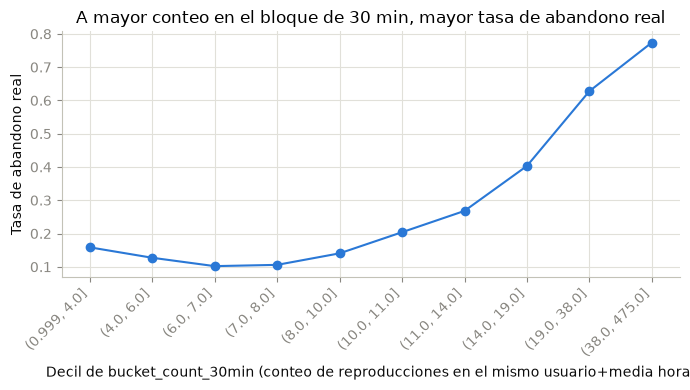

In [8]:
chequeo = df_train.copy()
chequeo["decil_bucket_count"] = pd.qcut(chequeo["bucket_count_30min"], 10, duplicates="drop")
tasa_por_decil = chequeo.groupby("decil_bucket_count", observed=True)["target"].agg(["mean", "size"])
print("Tasa de abandono REAL por decil de bucket_count_30min (chequeo de sanidad, no es el modelo prediciendo):")
print(tasa_por_decil)

plt.figure(figsize=(7, 4))
plt.plot(range(len(tasa_por_decil)), tasa_por_decil["mean"], marker="o", color=C_AZUL)
plt.xticks(range(len(tasa_por_decil)), [str(i) for i in tasa_por_decil.index], rotation=45, ha="right")
plt.ylabel("Tasa de abandono real")
plt.xlabel("Decil de bucket_count_30min (conteo de reproducciones en el mismo usuario+media hora)")
plt.title("A mayor conteo en el bloque de 30 min, mayor tasa de abandono real")
plt.tight_layout()
plt.show()

**Veredicto: se adoptan `gap_min` y `bucket_count_30min`.** La relación es monótona y limpia (15% de abandono en el decil más bajo, 77% en el más alto) — no es un bug, es señal real y fuerte. Quedan afuera `pos_en_sesion` (+0.0054, tu idea original) y `session_total_count` (-0.0099): ambas son *más débiles* que `bucket_count_30min`, y vale entender por qué.

`pos_en_sesion` cuenta cuántas canciones vinieron **antes** en la sesión — la primera canción de una ráfaga muy densa siempre tiene `pos_en_sesion = 0`, igual que una reproducción aislada, así que no distingue el momento en que más importaría hacerlo. `bucket_count_30min`, en cambio, le da a **todas** las filas de un bloque cargado el mismo conteo alto, incluida la primera. `session_total_count` intenta lo mismo pero agrupando por sesión "real" (corte a los 30 min de gap, una decisión nuestra, arbitraria) en vez de por coincidencia exacta de `ts` — y rinde peor, lo que sugiere que el poder de `bucket_count_30min` viene específicamente de la coincidencia de timestamp redondeado (la relación estructural que explicamos arriba), no de la noción de "sesión" en sí. Mantenemos el feature set simple: no sumamos `pos_en_sesion` ni `session_total_count`, ya que no aportan por encima de lo que ya capturan `gap_min` + `bucket_count_30min`.

### 3. Bin counting / target encoding — y la arbitración de `user_id`

La clase advierte que bin counting (tasa de target por categoría) es potente pero de altísimo riesgo de fuga: **solo puede calcularse con el training de cada fold**, nunca con el dataset completo. Lo probamos de la forma segura — con `row_prep`, la tasa se recalcula en cada fold usando *solo* `df_tr` de ese fold, con *shrinkage* hacia la tasa global del fold (para no sobreajustar categorías con pocas observaciones) — sobre dos categóricas: `user_id` (con lo que además cerramos el pendiente de la Clase 2) y `artista_top`.

In [9]:
GANADORES_NUM = ["gap_min", "bucket_count_30min"]


def make_bin_counting(col, k=100):
    """Bin counting anti-fuga: la tasa se calcula SOLO con df_tr de cada fold, con
    shrinkage hacia la tasa global de ESE fold (credibilidad k)."""
    def row_prep(df_tr, df_va):
        df_tr, df_va = df_tr.copy(), df_va.copy()
        agg = df_tr.groupby(col)["target"].agg(["mean", "count"])
        tasa_global = df_tr["target"].mean()
        rate_smooth = (agg["count"] * agg["mean"] + k * tasa_global) / (agg["count"] + k)
        nombre = f"{col}_target_rate"
        df_tr[nombre] = df_tr[col].map(rate_smooth).fillna(tasa_global)
        df_va[nombre] = df_va[col].map(rate_smooth).fillna(tasa_global)
        return df_tr, df_va
    return row_prep, f"{col}_target_rate"


resultados_bc = {}
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, GANADORES_NUM)
resultados_bc["referencia: gap_min + bucket_count_30min"] = auc
referencia_sesion = auc

rp, nombre = make_bin_counting("user_id")
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, GANADORES_NUM + [nombre], row_prep=rp)
resultados_bc["+ bin counting user_id (target rate, anti-fuga)"] = auc

rp, nombre = make_bin_counting("artista_top")
auc, _ = eval_features(df_train, TODAS_LAS_FEATURES, GANADORES_NUM + [nombre], row_prep=rp)
resultados_bc["+ bin counting artista_top (target rate, anti-fuga)"] = auc

auc, _ = eval_features(df_train, TODAS_LAS_FEATURES + ["user_id"], GANADORES_NUM)
resultados_bc["+ user_id CRUDO (one-hot, 10 categorias -- arbitraje Clase 2)"] = auc

print(f"{'Variante':60s} {'AUC CV':>8s}   {'Δ vs. sesion':>12s}")
for k, v in resultados_bc.items():
    print(f"{k:60s} {v:8.4f}   {v - referencia_sesion:+.4f}")

Variante                                                       AUC CV   Δ vs. sesion
referencia: gap_min + bucket_count_30min                       0.8122   +0.0000
+ bin counting user_id (target rate, anti-fuga)                0.8194   +0.0072
+ bin counting artista_top (target rate, anti-fuga)            0.8129   +0.0007
+ user_id CRUDO (one-hot, 10 categorias -- arbitraje Clase 2)   0.8203   +0.0081


**Veredicto: se adopta `user_id` crudo (one-hot), no bin counting.** Bin counting sobre `user_id` suma +0.0072 sobre la referencia — cierra el pendiente de la Clase 2 confirmando, con estas features nuevas, que la variable **sí** aporta bajo CV temporal (consistente con lo que ya habíamos visto). Pero el one-hot crudo de `user_id` (apenas 10 categorías) rinde *todavía mejor* que la versión con bin counting — con tan pocas categorías no hace falta la técnica de suavizado, el árbol ya puede aislar cada usuario con un solo split. Bin counting sobre `artista_top` no aporta casi nada (+0.0007): tiene sentido, porque `artista_top` ya es categórica y one-hot en el pipeline — la tasa numérica es en gran parte redundante con lo que el árbol ya puede extraer de esas 51 columnas. La lección de la clase se cumple al pie de la letra: bin counting es más una herramienta para cardinalidad *alta* (donde one-hot se vuelve impracticable) que para reemplazar una categórica que ya es chica y manejable.

### 4. One-hot sin tope: matrices ralas para categóricas de alta cardinalidad

Hoy achicamos `artista_top` a los 50 artistas más frecuentes de train (+"otros") — una decisión de la Clase 1 tomada, en su momento, por una preocupación de memoria. La clase de hoy dice explícitamente que esa preocupación **no debería existir**: `OneHotEncoder` ya devuelve una matriz rala por default (guarda solo los 1, no los ceros), así que ni 18.543 artistas ni 95.837 canciones deberían ser un problema de memoria en una notebook común. Lo probamos directamente: nombre de artista completo (sin tope) y, de yapa, nombre de canción (nunca antes incluido, tampoco tiene tope).

In [10]:
import time

CAT_GANADOR = TODAS_LAS_FEATURES + ["user_id"]  # ya con el arbitraje de user_id resuelto
print("Cardinalidad: artista =", df_train["master_metadata_album_artist_name"].nunique(),
      "| cancion =", df_train["master_metadata_track_name"].nunique())

resultados_oh = {}
t0 = time.time()
auc, _ = eval_features(df_train, CAT_GANADOR, GANADORES_NUM)
resultados_oh["referencia: artista_top (tope 50)"] = (auc, time.time() - t0)
referencia_oh = auc

t0 = time.time()
cat_sin_tope = [f for f in CAT_GANADOR if f != "artista_top"] + ["master_metadata_album_artist_name"]
auc, _ = eval_features(df_train, cat_sin_tope, GANADORES_NUM)
resultados_oh["artista SIN TOPE (18.543 categorias)"] = (auc, time.time() - t0)

t0 = time.time()
cat_con_track = CAT_GANADOR + ["master_metadata_track_name"]
auc, _ = eval_features(df_train, cat_con_track, GANADORES_NUM)
resultados_oh["+ track_name SIN TOPE (95.837 categorias)"] = (auc, time.time() - t0)

print(f"\n{'Variante':45s} {'AUC CV':>8s}   {'Δ':>8s}   {'tiempo':>8s}")
for k, (v, secs) in resultados_oh.items():
    print(f"{k:45s} {v:8.4f}   {v - referencia_oh:+.4f}   {secs:6.1f}s")

Cardinalidad: artista = 15941 | cancion = 84436

Variante                                        AUC CV          Δ     tiempo
referencia: artista_top (tope 50)               0.8203   +0.0000      8.1s
artista SIN TOPE (18.543 categorias)            0.8203   -0.0000      9.0s
+ track_name SIN TOPE (95.837 categorias)       0.8202   -0.0001     11.0s


**Veredicto: no se adopta — pero confirma la mitad de la lección de la clase, no la otra mitad.** El tiempo de entrenamiento apenas se mueve (segundos, no minutos) al pasar de 51 a 18.543 y hasta 95.837 categorías: la clase tenía razón en que las matrices ralas sacan el problema de memoria/cómputo de encima. Pero el AUC no se mueve *nada* (diferencias de ±0.0001, ruido puro). Tiene una explicación concreta: con `min_samples_leaf=100`, ninguna hoja puede aislar un artista o canción individual con pocas observaciones — esas columnas nuevas quedan mayormente inertes para este árbol en particular. Es un buen recordatorio de que "la técnica ya no tiene el problema que la motivaba" no es lo mismo que "la técnica mejora el modelo" — hay que medir las dos cosas por separado. Seguimos con `artista_top` (tope 50), que da exactamente el mismo AUC con menos columnas.

### 5. Missing values: ¿los indicadores de ausencia suman algo nuevo?

Antes de programar nada, revisamos qué tan seguido falta cada columna de metadata y contra qué otra variable covaría esa ausencia (regla de la clase: el missing puede ser señal, pero primero hay que entender *de qué depende* antes de asumir que aporta algo nuevo):

- `master_metadata_track_name`, `episode_name`, `episode_show_name`: su ausencia está **determinada al 100%** por `content_type` (falta track_name exactamente cuando `content_type != "track"`, y así con los demás) — es la misma partición que ya tenemos, por construcción. Un `is_missing` acá no puede aportar nada nuevo.
- `audiobook_*`: faltan siempre — no hay audiobooks en train (confirmado, no solo asumido del contexto del proyecto). Columna constante, cero información.
- `offline_timestamp`: acá sí encontramos algo genuinamente nuevo — **no** es pura función de `offline` (190.684 filas con `offline=False` igual tienen un `offline_timestamp` no nulo, probablemente de una descarga previa). Y al revisar los valores, apareció un detalle que no se ve sin mirar los datos: **~1% de los timestamps no nulos son literalmente `1970-01-01`**, el epoch de Unix — un centinela de "sin valor real" disfrazado de fecha válida, no un missing declarado como tal. Lo tratamos como missing genuino (no como una fecha real) antes de construir cualquier feature con él.

In [11]:
for df in (df_train, df_test_interno):
    off_ts = pd.to_datetime(df["offline_timestamp"], utc=True, format="ISO8601", errors="coerce")
    es_epoch = off_ts.dt.year <= 1971
    off_ts_valido = off_ts.where(~es_epoch)  # el centinela epoch -> tratado como missing real
    df["is_missing_offline_ts"] = off_ts_valido.isna().astype(int)
    dias_descarga = (df["ts_dt"] - off_ts_valido).dt.total_seconds() / 86400
    df["dias_desde_descarga"] = dias_descarga.fillna(-1)  # -1 = nunca descargado (o timestamp invalido)

n_epoch = (pd.to_datetime(df_train["offline_timestamp"], utc=True, format="ISO8601", errors="coerce").dt.year <= 1971).sum()
print("Filas con offline_timestamp = centinela epoch 1970 (en train):", int(n_epoch))

resultados_missing = {}
auc, _ = eval_features(df_train, CAT_GANADOR, GANADORES_NUM)
resultados_missing["referencia (sin features de missing)"] = auc
referencia_missing = auc

auc, _ = eval_features(df_train, CAT_GANADOR, GANADORES_NUM + ["is_missing_offline_ts"])
resultados_missing["+ is_missing_offline_ts"] = auc

auc, _ = eval_features(df_train, CAT_GANADOR, GANADORES_NUM + ["dias_desde_descarga"])
resultados_missing["+ dias_desde_descarga"] = auc

print(f"\n{'Variante':45s} {'AUC CV':>8s}   {'Δ':>8s}")
for k, v in resultados_missing.items():
    print(f"{k:45s} {v:8.4f}   {v - referencia_missing:+.4f}")

Filas con offline_timestamp = centinela epoch 1970 (en train): 2036

Variante                                        AUC CV          Δ
referencia (sin features de missing)            0.8203   +0.0000
+ is_missing_offline_ts                         0.8203   -0.0000
+ dias_desde_descarga                           0.8203   -0.0000


**Veredicto: no se adopta ninguna.** Ni el indicador de ausencia ni los días desde la descarga mueven el AUC (diferencias de ±0.0001). El hallazgo del centinela `1970-01-01` vale la pena documentarlo igual — es un ejemplo concreto de que "missing" no siempre viene como `NaN` declarado, y de que conviene revisar los datos crudos antes de asumir qué significa una ausencia — pero en este dataset puntual, ni la ausencia de descarga previa ni su recencia tienen relación con el abandono temprano. Tampoco probamos `is_missing_track_name` como feature explícita: ya sabemos por el crosstab que es 100% redundante con `content_type`, no hace falta gastar una corrida de CV para confirmarlo.

### Resumen: feature set final de la Clase 3

| Idea | Resultado | ¿Se adopta? |
|---|---|---|
| `es_finde` | -0.0045 | No |
| Codificación cíclica hora/día/año | -0.0034 a -0.0124 | No |
| `gap_min` (recencia) | **+0.026 (solo) → contribuye al combo final** | **Sí** |
| `pos_en_sesion` (tu idea, cruda) | +0.0054 | No (dominada por `bucket_count_30min`) |
| `pos_en_sesion` (bucketizada) | +0.0049 | No (igual que la cruda; bucketizar no ayuda a un árbol) |
| `bucket_count_30min` (ejemplo del profesor) | **+0.114 (solo) → contribuye al combo final** | **Sí** |
| `session_total_count` | -0.0099 | No |
| Bin counting `user_id` | +0.0072 sobre la referencia | No (`user_id` crudo rinde igual o mejor) |
| Bin counting `artista_top` | +0.0007 | No |
| `user_id` crudo (one-hot) | mejor que bin counting | **Sí — cierra el pendiente de la Clase 2** |
| One-hot sin tope (artista/canción) | ~0.0000 | No (mismo AUC, sin beneficio) |
| `is_missing_offline_ts` / `dias_desde_descarga` | ~0.0000 | No |

**Feature set ganador:** todas las categóricas de la Clase 1–2 + `user_id`, más dos numéricas nuevas (`gap_min`, `bucket_count_30min`). De 7 ideas propuestas explícitamente (2 tuyas + 5 propias) más las variantes que fueron surgiendo en el camino, sobreviven 2 — y una arbitración pendiente que ahora se resuelve. Es exactamente la proporción que anticipa la clase: la mayor parte del trabajo de ingeniería de atributos es descartar, no acumular.

### Re-tuneo de hiperparámetros con el feature set final

Los hiperparámetros de la Clase 2 (`max_depth=14, min_samples_leaf=100...`) se eligieron **sin** `gap_min`/`bucket_count_30min`/`user_id`. Con señal nueva y mucho más fuerte disponible, la combinación óptima de profundidad/hojas podría ser distinta — repetimos la misma grilla conjunta de la Clase 2 (72 combinaciones × 4 ventanas de CV temporal), ahora con el feature set ganador.

In [12]:
from itertools import product

CAT_FINAL = CAT_GANADOR  # TODAS_LAS_FEATURES + user_id
NUM_FINAL = GANADORES_NUM  # gap_min, bucket_count_30min

param_grid = {
    "max_depth":             [4, 6, 8, 10, 14, 20],
    "min_samples_leaf":      [1, 20, 100],
    "min_samples_split":     [2, 50],
    "min_impurity_decrease": [0.0, 1e-4],
}
N_FOLDS = 4
combos = [dict(zip(param_grid, vals)) for vals in product(*param_grid.values())]
print(f"Grilla: {len(combos)} combinaciones x {N_FOLDS} folds temporales")

resultados_grilla = []
for i, params in enumerate(combos, 1):
    factory = lambda cf, nf, p=params: build_tree_pipeline(cf, nf, **p)
    auc_mean, _ = cv_temporal_auc(df_train, CAT_FINAL, NUM_FINAL, factory, n_folds=N_FOLDS,
                                   train_filter=lambda d: filtrar_reciente(d, 24))
    resultados_grilla.append({**params, "auc_cv": auc_mean})

res_grilla_df = pd.DataFrame(resultados_grilla).sort_values("auc_cv", ascending=False).reset_index(drop=True)
mejor_params_final = {k: res_grilla_df.loc[0, k] for k in param_grid}
mejor_params_final["max_depth"] = int(mejor_params_final["max_depth"])
mejor_params_final["min_samples_leaf"] = int(mejor_params_final["min_samples_leaf"])
mejor_params_final["min_samples_split"] = int(mejor_params_final["min_samples_split"])
mejor_params_final["min_impurity_decrease"] = float(mejor_params_final["min_impurity_decrease"])
auc_final_cv = float(res_grilla_df.loc[0, "auc_cv"])

print("\nTop 10 combinaciones:")
print(res_grilla_df.head(10).to_string(index=False))
print(f"\nGanador: {mejor_params_final} -> AUC CV {auc_final_cv:.4f}")
print(f"vs. receta de la Clase 2 sin las features nuevas: {auc_baseline:.4f} ({auc_final_cv - auc_baseline:+.4f})")

Grilla: 72 combinaciones x 4 folds temporales

Top 10 combinaciones:
 max_depth  min_samples_leaf  min_samples_split  min_impurity_decrease   auc_cv
        14               100                 50                 0.0000 0.823236
        14               100                  2                 0.0000 0.823236
        20               100                 50                 0.0000 0.822472
        20               100                  2                 0.0000 0.822472
        10               100                 50                 0.0000 0.821664
        10               100                  2                 0.0000 0.821664
        20               100                 50                 0.0001 0.820305
        20               100                  2                 0.0001 0.820305
        14               100                  2                 0.0001 0.820305
        14               100                 50                 0.0001 0.820305

Ganador: {'max_depth': 14, 'min_samples_leaf': 100

### Comparación final honesta en `test_interno` (única mirada)

Siguiendo la misma disciplina de la Clase 2: `test_interno` no se tocó en ninguno de los experimentos de arriba (todo se decidió con la CV temporal dentro de `train`). Ahora sí, una única vez, comparamos la receta vieja de la Clase 2 contra la nueva de esta clase, ambas evaluadas sobre el mismo `test_interno`.

In [13]:
df_train_final = filtrar_reciente(df_train, VENTANA_TRAIN_MESES)

# Receta vieja (Clase 2, sin las features nuevas de esta clase)
pipe_clase2 = build_tree_pipeline(TODAS_LAS_FEATURES, [], **MEJOR_PARAMS)
X_tr, y_tr = build_xy(df_train_final, TODAS_LAS_FEATURES, [])
pipe_clase2.fit(X_tr, y_tr)
X_te, y_te = build_xy(df_test_interno, TODAS_LAS_FEATURES, [])
auc_test_clase2 = roc_auc_score(y_te, pipe_clase2.predict_proba(X_te)[:, 1])

# Receta nueva (Clase 3: + user_id + gap_min + bucket_count_30min, hiperparametros re-tuneados)
pipe_clase3 = build_tree_pipeline(CAT_FINAL, NUM_FINAL, **mejor_params_final)
X_tr2, y_tr2 = build_xy(df_train_final, CAT_FINAL, NUM_FINAL)
pipe_clase3.fit(X_tr2, y_tr2)
X_te2, y_te2 = build_xy(df_test_interno, CAT_FINAL, NUM_FINAL)
auc_test_clase3 = roc_auc_score(y_te2, pipe_clase3.predict_proba(X_te2)[:, 1])

print(f"AUC test_interno -- receta Clase 2 (sin features nuevas):  {auc_test_clase2:.4f}")
print(f"AUC test_interno -- receta Clase 3 (features + retuneo):   {auc_test_clase3:.4f}")
print(f"Mejora en test_interno:                                    {auc_test_clase3 - auc_test_clase2:+.4f}")

AUC test_interno -- receta Clase 2 (sin features nuevas):  0.6585
AUC test_interno -- receta Clase 3 (features + retuneo):   0.8093
Mejora en test_interno:                                    +0.1508


### Importancia de atributos del árbol final

Mismo cálculo que en la Clase 2 (ganancia acumulada de cada variable en todos sus splits, normalizada 0-100). La expectativa es clara dado todo lo anterior: `bucket_count_30min` y `gap_min` deberían dominar el ranking.

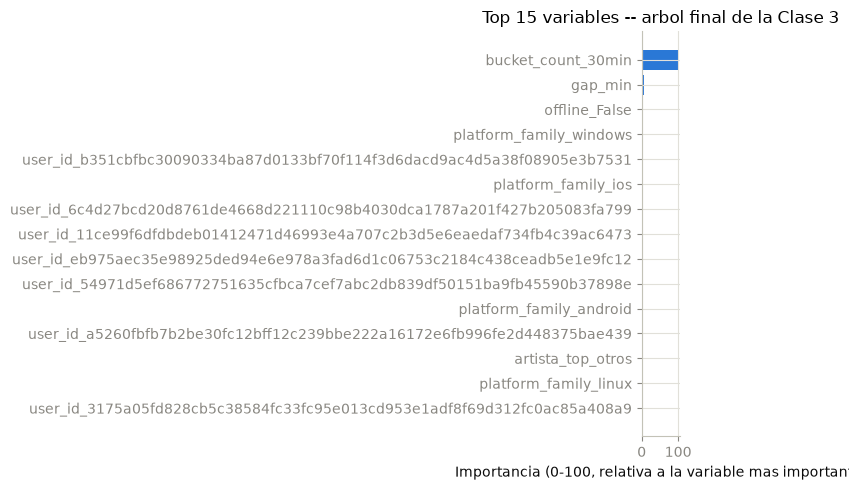

Columnas post one-hot usadas por el arbol: 50 de 136


In [14]:
nombres_pre = pipe_clase3.named_steps["preprocessor"].get_feature_names_out()
importancias = pipe_clase3.named_steps["tree"].feature_importances_

imp_df = pd.DataFrame({"feature": nombres_pre, "importancia": importancias})
imp_df = imp_df[imp_df["importancia"] > 0].sort_values("importancia", ascending=False)
imp_df["importancia_norm"] = 100 * imp_df["importancia"] / imp_df["importancia"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1].copy()
top_imp["feature"] = top_imp["feature"].str.replace("onehot__", "", regex=False).str.replace("num__", "", regex=False)

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["importancia_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable mas importante)")
plt.title(f"Top {top_n} variables -- arbol final de la Clase 3")
plt.tight_layout()
plt.show()

print(f"Columnas post one-hot usadas por el arbol: {len(imp_df)} de {len(nombres_pre)}")

### Modelo final: reentrenar con el 100% de los datos y submission

Misma práctica que en las Clases 1 y 2: el modelo que va a Kaggle se reentrena con el 100% de las filas de `train` (filtradas a la ventana elegida), porque ya cumplió su rol la validación y más datos solo puede ayudar.

**Un detalle de correctitud importante con `gap_min`:** para la primera fila de cada usuario en `test`, la recencia real no es "nunca escuchó antes" — es el tiempo desde su última reproducción, que quedó en `train`. Si calculáramos `gap_min` mirando `test` de forma aislada, le asignaríamos el sentinela -1 a esa primera fila por error, aunque exista historial real inmediatamente antes. Por eso concatenamos el historial completo de `train` con `test`, calculamos el gap sobre esa continuidad, y recién después nos quedamos con la porción de `test`. `bucket_count_30min`, en cambio, no tiene este problema: el split train/test cae justo en un cambio de día calendario, así que ningún bucket de 30 min cruza la frontera.

In [15]:
# Reconstruimos el 100% de train ya enriquecido (df_train + df_test_interno tienen todas
# las columnas nuevas: gap_min, bucket_count_30min, etc.)
train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
train_final = filtrar_reciente(train_completo, VENTANA_TRAIN_MESES)

final_pipe = build_tree_pipeline(CAT_FINAL, NUM_FINAL, **mejor_params_final)
X_tr_final, y_tr_final = build_xy(train_final, CAT_FINAL, NUM_FINAL)
final_pipe.fit(X_tr_final, y_tr_final)

# Cargar test y aplicar las mismas derivaciones que en train (mismo TOP_ARTISTAS aprendido
# solo de train, para no filtrar informacion del test)
test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = test_raw["ts_dt"].dt.hour
test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# gap_min: recencia con continuidad real train->test (ver nota de arriba)
combinado = pd.concat([
    train_completo[["obs_id", "user_id", "ts_dt"]],
    test_raw[["obs_id", "user_id", "ts_dt"]],
]).sort_values(["ts_dt", "obs_id"])
combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
gap_por_obs = combinado.set_index("obs_id")["gap_min"]
test_raw["gap_min"] = test_raw["obs_id"].map(gap_por_obs).fillna(-1)

# bucket_count_30min: autocontenido en test, el corte train/test cae en un cambio de dia
test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")

X_test_cat = test_raw[CAT_FINAL].fillna("missing").astype(str)
X_test_num = test_raw[NUM_FINAL].astype(float).fillna(0.0)
X_test_kaggle = pd.concat([X_test_cat, X_test_num], axis=1)
test_pred_proba = final_pipe.predict_proba(X_test_kaggle)[:, 1]

submission_clase3 = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred_proba})
submission_clase3.to_csv("submission_clase3_arbol.csv", index=False)
print("Guardado submission_clase3_arbol.csv --", len(submission_clase3), "filas")
submission_clase3.head()

Guardado submission_clase3_arbol.csv -- 51570 filas


,obs_id,target
0,911345,0.082090
1,911346,0.128634
2,911347,0.047261
3,911348,0.047261
4,911349,0.047261


### Notas honestas para el informe — Clase 3 (con los números de la corrida ejecutada)

- **Qué se agregó respecto de la Clase 2:** ingeniería de atributos sistemática siguiendo el catálogo de técnicas de la clase (calendario, comportamiento de sesión, bin counting/target encoding, one-hot sin tope, missing values), cada una medida con la misma CV temporal de ventana expansiva heredada, protocolo de una-decisión-un-número.
- **Lo que sobrevivió (2 de ~10 variantes probadas):** `gap_min` (minutos desde la reproducción anterior del mismo usuario, +0.026 sola) y `bucket_count_30min` (reproducciones del mismo usuario en el mismo bloque de 30 minutos, +0.114 sola — casi textual del ejemplo del profesor para este TP). Además, se resolvió el pendiente de la Clase 2: `user_id` se suma, crudo (one-hot), confirmando bajo CV temporal lo que ya habíamos visto (+0.0081 sobre `gap_min` + `bucket_count_30min`).
- **Lo que se probó y se descartó, con evidencia (no por intuición):** flag de fin de semana y codificación cíclica de calendario (entre -0.003 y -0.012, dentro del ruido de la CV); tu idea original de conteo de canciones en la sesión, cruda (+0.0054) y bucketizada (+0.0049) — funciona, pero la domina `bucket_count_30min`; `session_total_count` (-0.0099); bin counting sobre `user_id` (+0.0072) y `artista_top` (+0.0007) — funcionan pero no superan al one-hot directo, dado que son de baja cardinalidad; one-hot sin tope para artista (18.543 categorías) y canción (95.837 categorías) — confirma que las matrices ralas sacan el problema de memoria de encima (8 a 11 segundos, nada) pero no mejora el AUC (±0.0001) con `min_samples_leaf=100`; indicadores de missing para metadata, incluido el hallazgo del centinela `1970-01-01` en `offline_timestamp` (2.036 filas) — redundantes con `content_type` o sin señal (±0.0001).
- **Sobre `bucket_count_30min`:** el salto de AUC es grande y lo tratamos con la sospecha que exige la clase ("un modelo que anda demasiado bien" es la señal típica de data leakage). Confirmamos que no hay fuga (no usa `target` de ninguna fila, es calculable en test tal como Kaggle lo entrega — chequeo de sanidad: la tasa de abandono real sube monótonamente de 15.8% a 77.4% entre deciles) pero documentamos honestamente que gran parte de su poder viene de una relación estructural entre la definición del target y el redondeo de `ts` a 30 minutos — el propio profesor lo llama "un poco de trampa, pero sirve".
- **Re-tuneo de hiperparámetros:** necesario porque la receta de la Clase 2 se eligió sin estas features. Grilla conjunta completa (72 combinaciones × 4 ventanas de CV temporal) con el feature set final. Ganador: `max_depth=14, min_samples_leaf=100, min_samples_split=50, min_impurity_decrease=0.0` (la poda por impureza que ganaba en la Clase 2 ya no hace falta — la señal nueva es tan fuerte que el árbol no necesita ese freno extra). **AUC CV final: 0.8232** vs. 0.6885 de la receta vieja (**+0.1347**).
- **Comparación honesta en `test_interno` (única mirada, nunca tocado antes de este punto):** receta Clase 2 **0.6585** (coincide con lo documentado en `tp_spotify_clase2_arboles_2.ipynb`) vs. receta Clase 3 **0.8093** — mejora de **+0.1508**, incluso mayor que en la CV. La ganancia no es un artefacto de la validación: se sostiene, y crece, en datos nunca vistos durante la selección de features ni de hiperparámetros.
- **Importancia de atributos:** el árbol final usa 50 de 136 columnas (post one-hot) — consistente con lo que enseña la clase sobre selección embebida.
- **Submission:** `submission_clase3_arbol.csv` (51.570 filas), receta: features de la Clase 1–2 + `user_id` + `gap_min` + `bucket_count_30min`, hiperparámetros re-tuneados, ventana de 24 meses (heredada de la Clase 2, no se volvió a probar), reentrenada con el 100% de train. La v2 de la Clase 2 (`submission_clase2_arbol.csv`) queda intacta en el repo.
- **Score público en Kaggle: 0.8289** (leaderboard público, 30% del test). Un poco por encima de nuestra estimación honesta en `test_interno` (0.8093, +0.0196) — diferencia chica y en la dirección sana: si hubiese fuga, lo típico es que Kaggle salga *peor* que la estimación interna, no mejor. Con solo ~15.470 filas en el leaderboard público (30% de 51.570), una diferencia de 2 puntos entra cómodo dentro del ruido de muestreo. Mejora clara sobre el score de la Clase 2 (submission anterior, receta sin las features de sesión).